In [1]:
# analyse different systems with the same spectral radius and see how the vector orthogonal to the subspace develops

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from sf_workingdir_lilly.dmlab.custom_esn_analysis import get_hidden_states_iso_feat, len_new_orth_vec, get_time_of_threshold_crossing, exp_func, stable_trials

In [3]:
spec_rad = 1.2
time_steps = 70

Hippo_n_feature = 16
Hippo_R = 8
Hippo_L = 64
#trial=6
fixed_whh=True
fixed_wih=True
folder = 'weights1.2'

x_vals = np.arange(1,70)

In [4]:
x_vals = np.arange(1,70)
#fig, ax = plt.subplots(10,5, figsize=(25,50), sharey=True, sharex=True)

orth_vec_lens = np.zeros((50, Hippo_n_feature, time_steps-1))

for t in range(50):
    for i in range(Hippo_n_feature):
        hs = get_hidden_states_iso_feat(time_steps, spec_rad, Hippo_n_feature, Hippo_R, Hippo_L, t, fixed_whh, fixed_wih, input_idx=i, weights_folder=folder)
        try:
            len_orth_vectors = len_new_orth_vec(hs, time_steps)
            #ax[t//5, t%5].scatter(x_vals, len_orth_vectors, label=f'{i}', s=5)
            orth_vec_lens[t, i, :] = len_orth_vectors
        except Exception as e:
            print(f'Could not compute length of orthogonal vectors for trial {t} and input neuron {i}: {e}')
            pass
        #ax[t//5, t%5].set_title(f'{t}')

In [5]:
thresh_crossed = get_time_of_threshold_crossing(orth_vec_lens)
print(thresh_crossed)

[31. 13. 32. 12. 12. 21. 18. 12. 49. 22. 21. 15. 34.  7. 31.  8. 11. 13.
 20. 28. 13.  8. 15. 29. 12. 30. 21.  7. 18. 16. 37. 23. 14. 19. 33. 52.
 39. 40. 34. 10. 37.  8. 17. 13. 31. 23. 12. 22. 12. 14.]


In [6]:
# fit an exponential curve to the length of the orthogonal vector over time
a_vals = np.zeros(50)
tau_vals = np.zeros(50)
y_vals = np.zeros((50, time_steps-1))
ys = orth_vec_lens.copy()

for t in range(50):
    a0 = orth_vec_lens[t, 0, 0]
    tau0 = 5.0
    popt, pcov = curve_fit(exp_func, x_vals, ys[t, 0, :], p0=[a0, tau0])
    a_fit, tau_fit = popt
    a_vals[t] = a_fit
    tau_vals[t] = tau_fit
    y_vals[t, :] = exp_func(x_vals, a_fit, tau_fit)

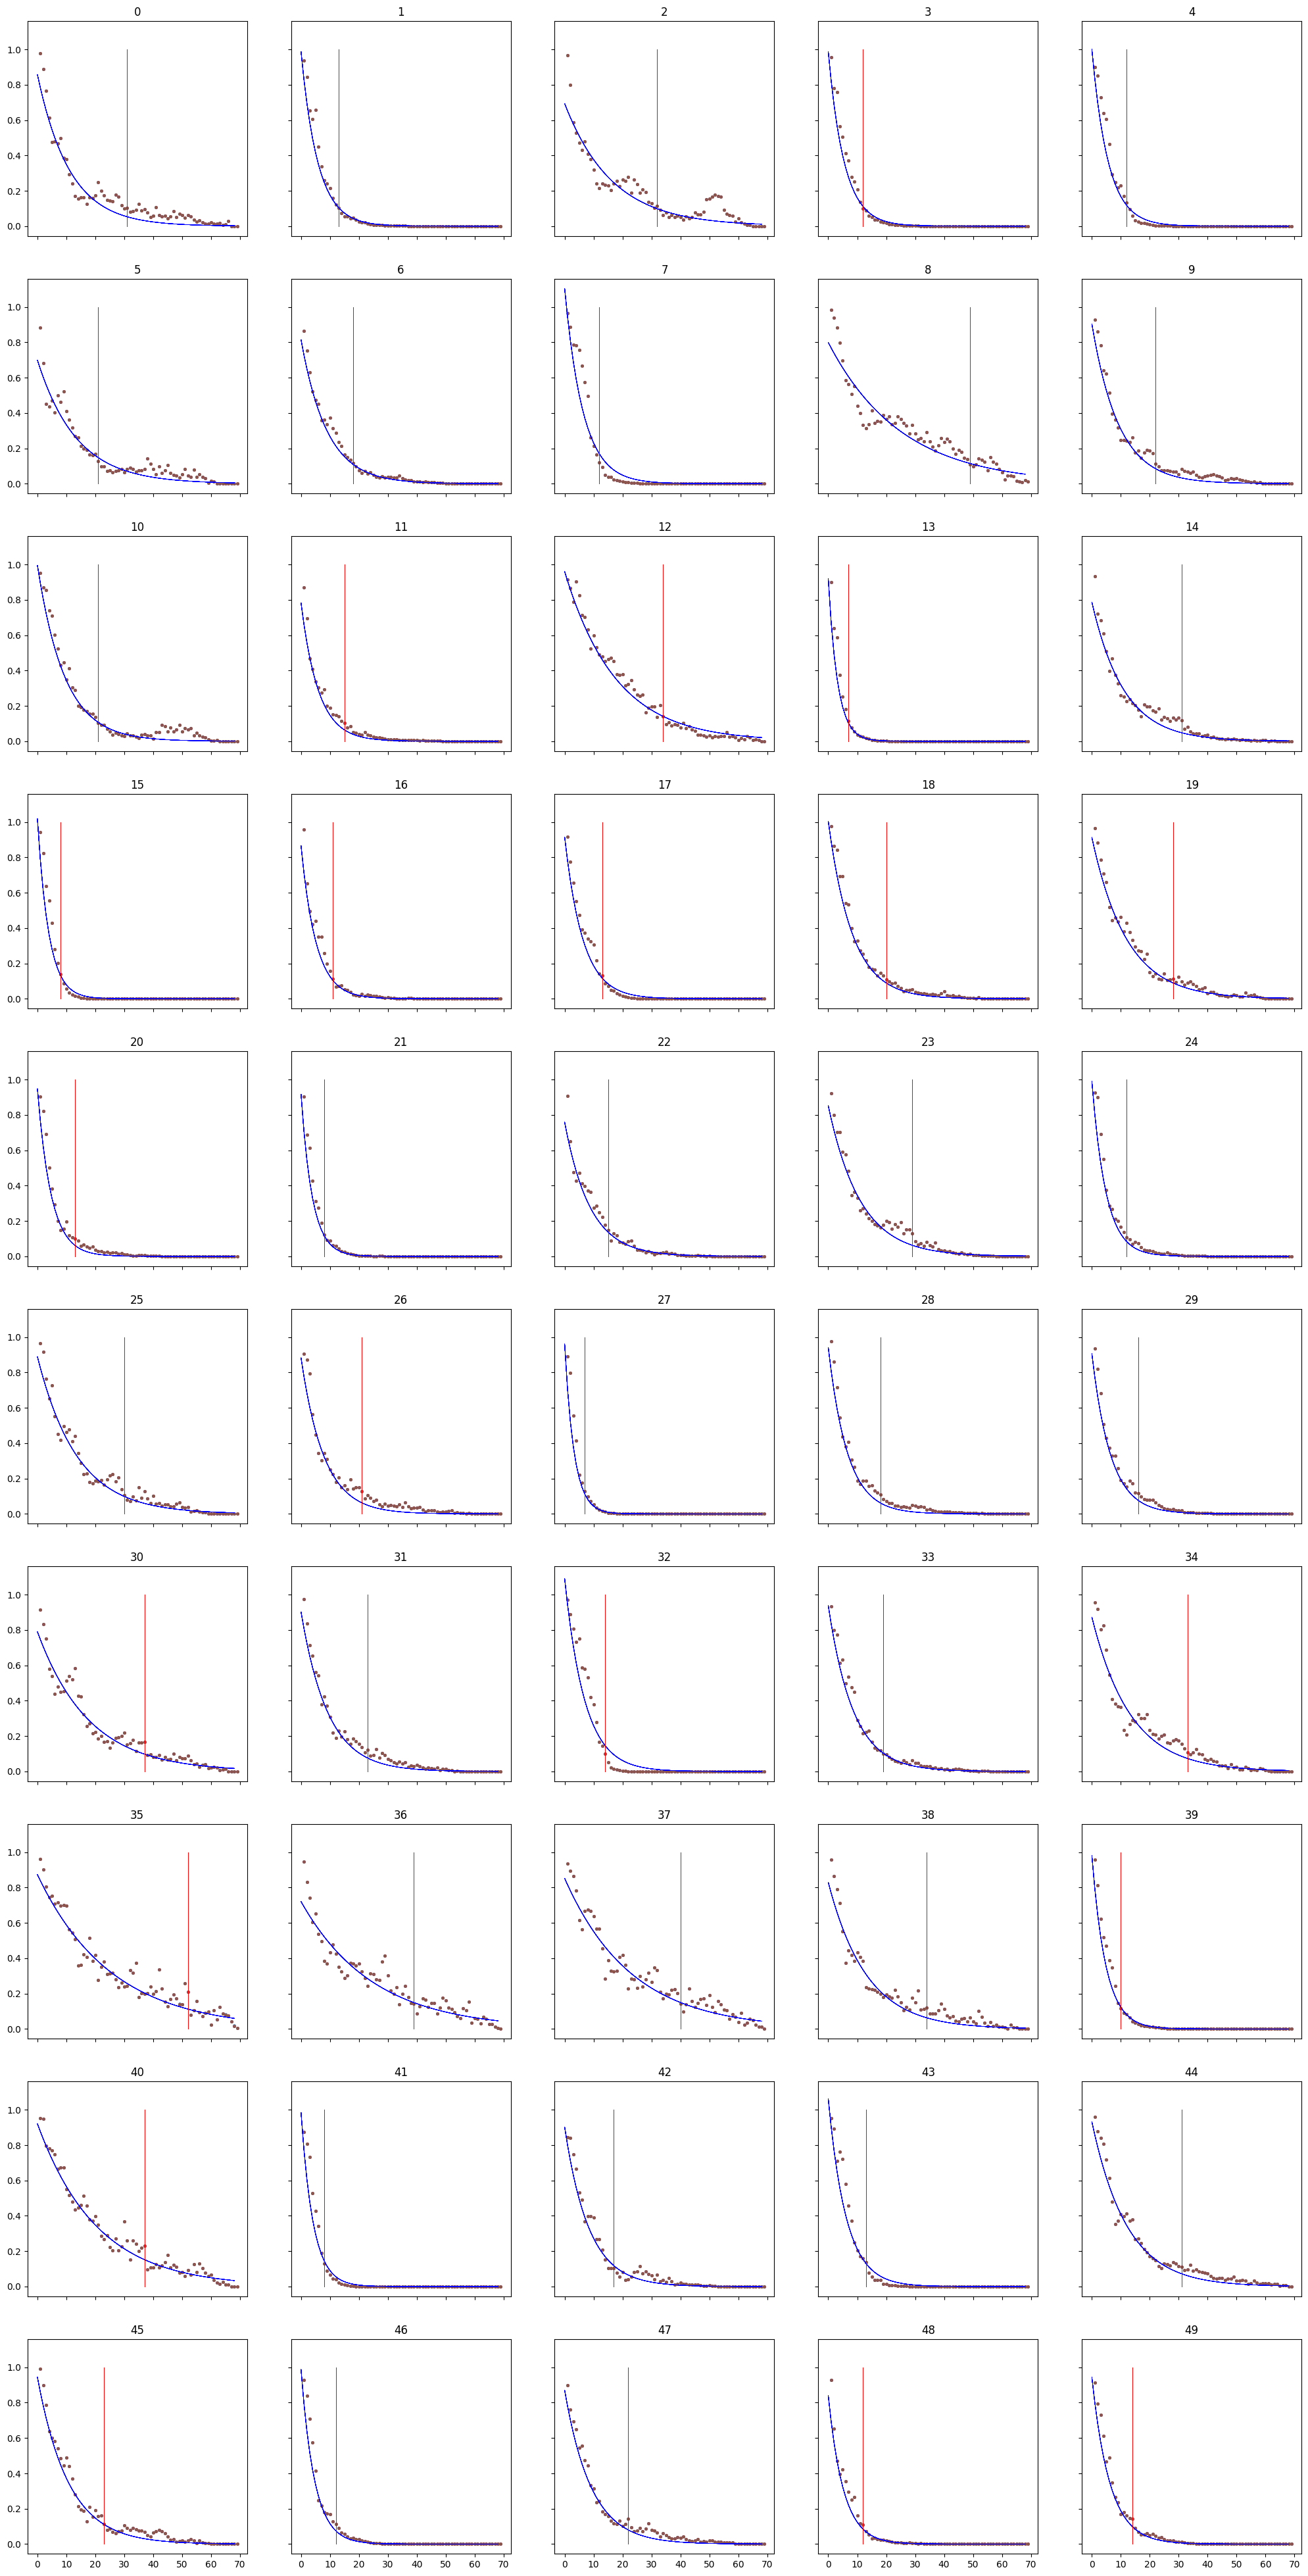

In [7]:
# plot the lengths of the orthogonal vectors
fig, ax = plt.subplots(10,5, figsize=(25,50), sharey=True, sharex=True)
for t in range(50):
    for i in range(Hippo_n_feature):
        ax[t//5, t%5].scatter(x_vals, orth_vec_lens[t, i, :], label=f'{i}', s=5)
        ax[t//5, t%5].plot(y_vals[t, :], c='b',linewidth=0.5)
        ax[t//5, t%5].set_title(f'{t}')
        ax[t//5, t%5].vlines(thresh_crossed[t], ymin=0, ymax=1, colors='r', linewidths=0.5)

In [8]:
neuron_norms_for_srs = np.zeros((50, time_steps))

for t in range(50):
    #for i in range(Hippo_n_feature):
    hs = get_hidden_states_iso_feat(time_steps, spec_rad, Hippo_n_feature, Hippo_R, Hippo_L, t, fixed_whh, fixed_wih, input_idx=0)
      
    neuron_norms_for_srs[t, :] = hs.norm(dim=1)
        

In [9]:
# get the trials sorted by their tau values and threshold crossing times
idx_sorted_tau = np.argsort(-tau_vals)
idx_sorted_thresh_crossed = np.argsort(-thresh_crossed)

print(idx_sorted_tau)
#print(tau_vals[idx_sorted_tau])
print(idx_sorted_thresh_crossed)
#print(thresh_crossed[idx_sorted_thresh_crossed])

[35  8 36 37 40 12 30  2 25  5 34 38 44 19  0 23 14 45 10  9 31 47  6 22
 33 42 18 26 32 28 29  7 17 43 49 11  1  4  3 48 16 24 39 20 46 41 15 21
 27 13]
[35  8 37 36 40 30 12 38 34  2 14 44  0 25 23 19 45 31  9 47  5 10 26 18
 33  6 28 42 29 11 22 32 49 20  1 17 43  3  7 24 48  4 46 16 39 41 15 21
 27 13]


In [10]:
# see the stable trials sorted by their tau values and threshold crossing times
stable_trials_idx = stable_trials(neuron_norms_for_srs)
print(stable_trials_idx)
print('######################################')

m = np.isin(idx_sorted_tau, stable_trials_idx)
stable_sorted_tau = idx_sorted_tau[m]
print(stable_sorted_tau)

m = np.isin(idx_sorted_thresh_crossed, stable_trials_idx)
stable_sorted_thresh = idx_sorted_thresh_crossed[m]
print(stable_sorted_thresh)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 42 43 44 45 46 47 48 49]
######################################
[35  8 36 37 40 12 30  2 25  5 34 38 44 19  0 23 14 45 10  9 31 47  6 33
 42 18 26 32 28 29  7 17 43 49 11  1  4  3 48 16 24 39 20 46 15 21 27 13]
[35  8 37 36 40 30 12 38 34  2 14 44  0 25 23 19 45 31  9 47  5 10 26 18
 33  6 28 42 29 11 32 49 20  1 17 43  3  7 24 48  4 46 16 39 15 21 27 13]


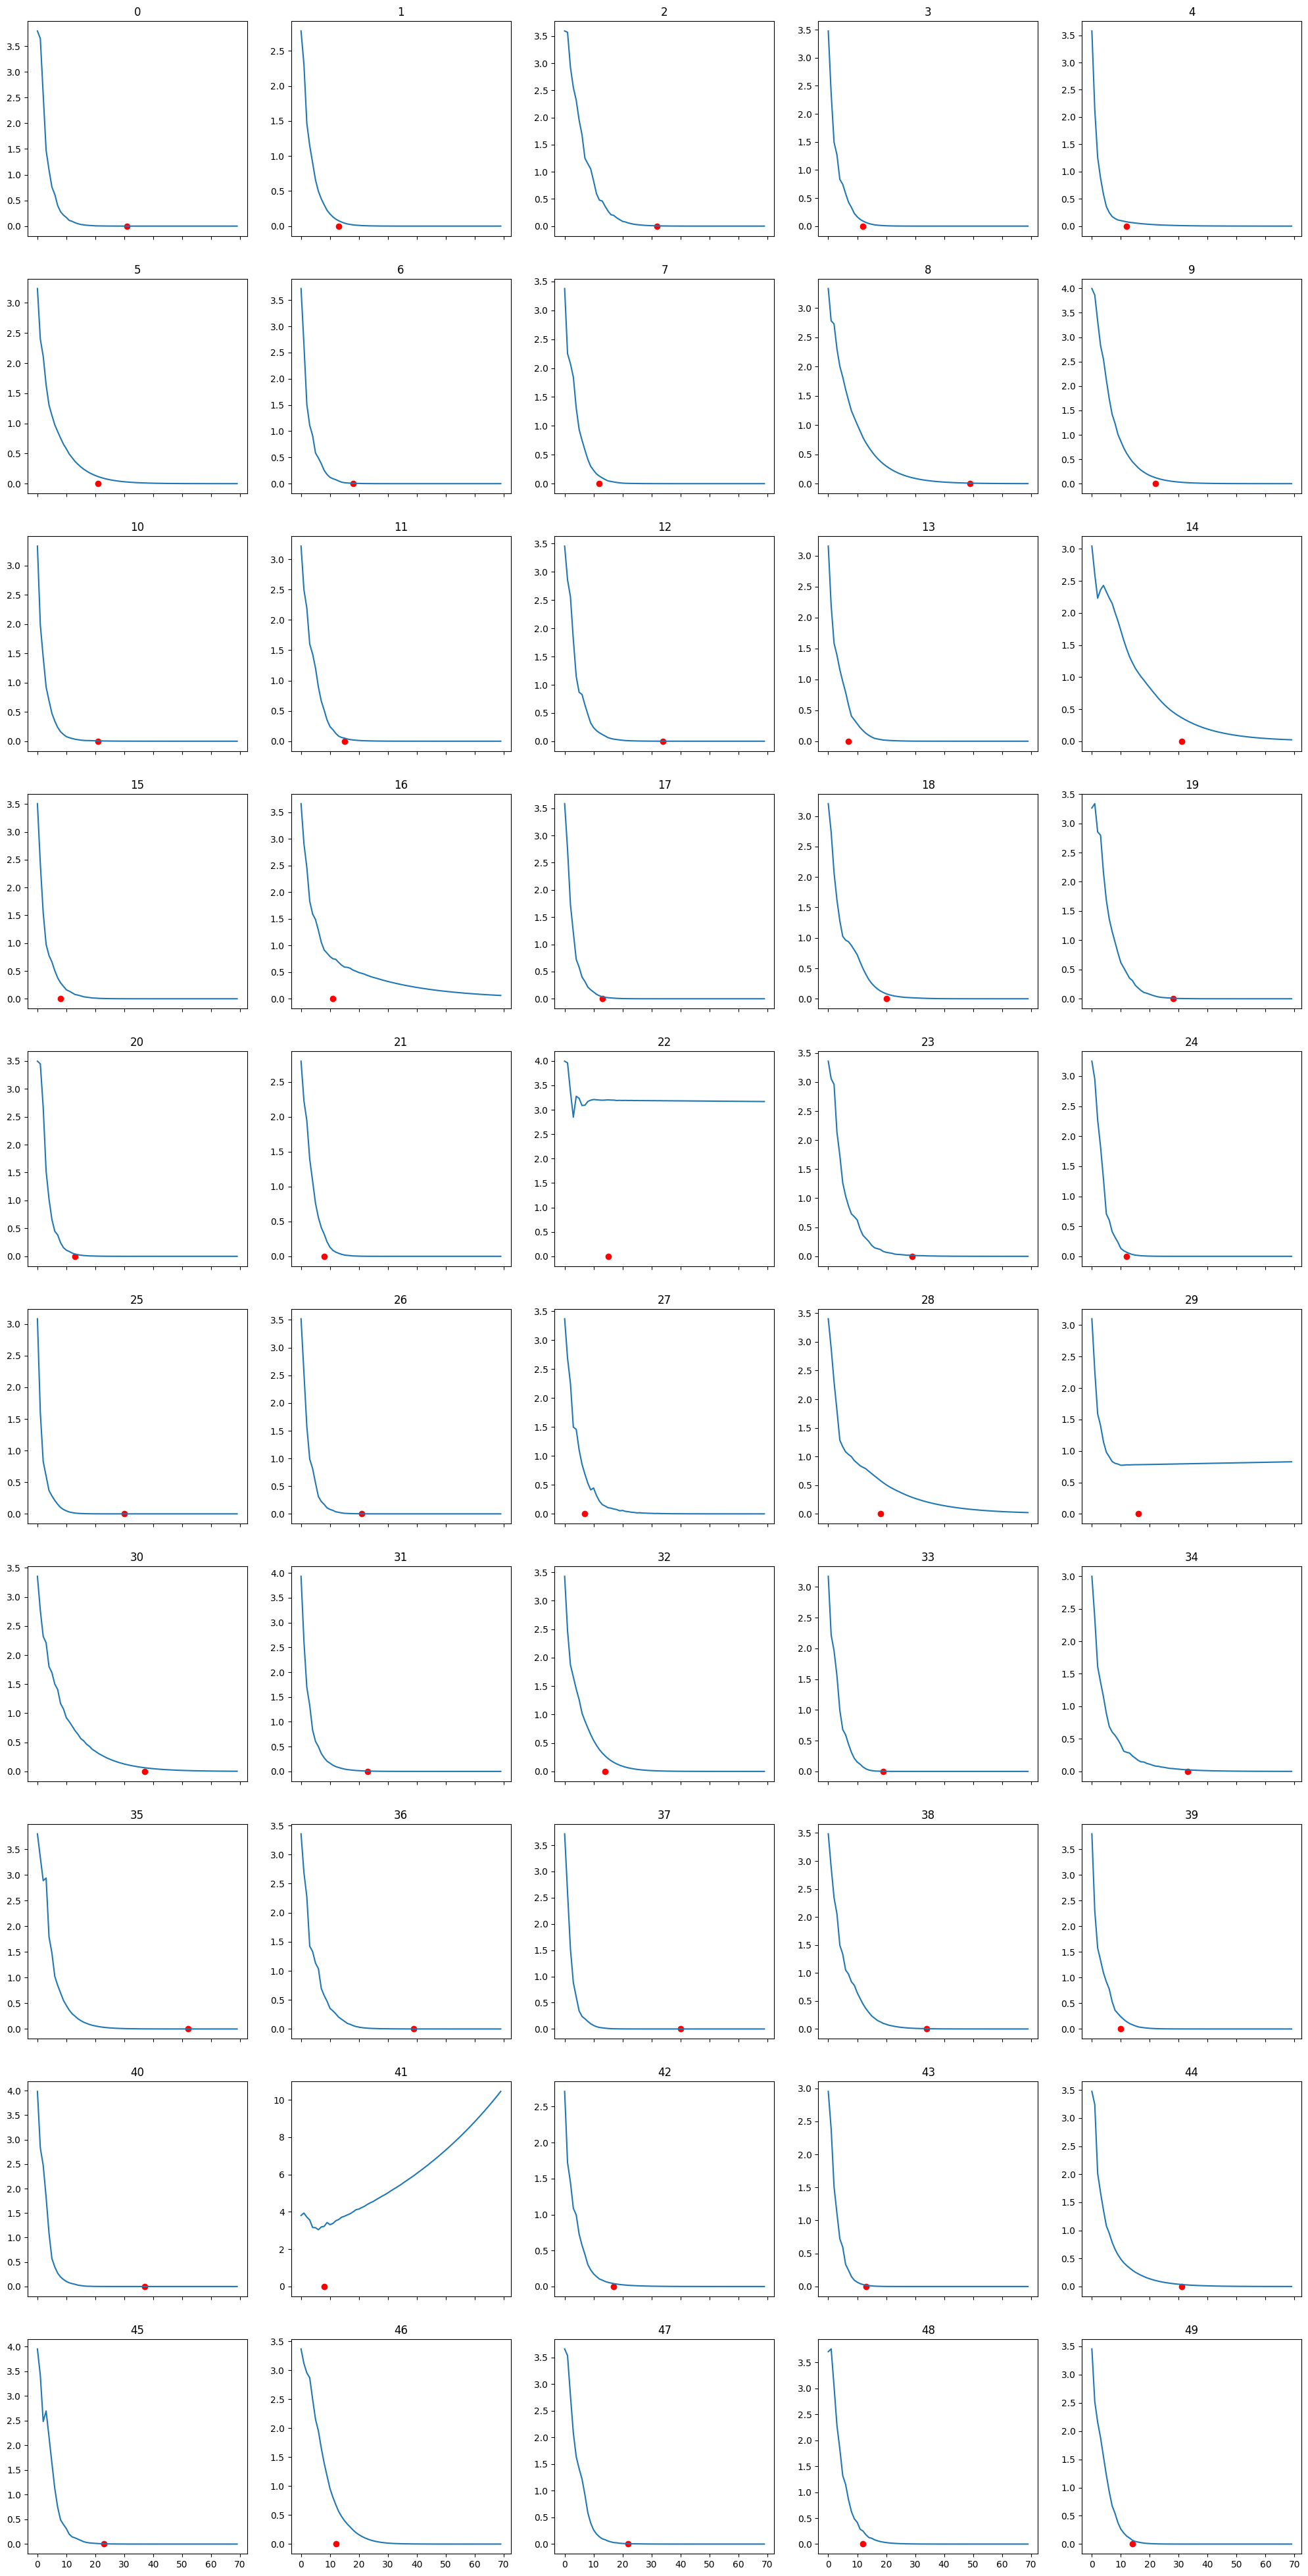

In [11]:
# plot the norms of the different weights
x_vals = np.arange(1,70)
fig, ax = plt.subplots(10,5, figsize=(25,50), sharex=True)
for t in range(50):
    #for i in range(Hippo_n_feature):
    ax[t//5, t%5].plot(neuron_norms_for_srs[t, :])
    ax[t//5, t%5].set_title(f'{t}')
    ax[t//5, t%5].scatter(thresh_crossed[t], 0, c='r')

